# 10) Optimizacion de Hiperparametros con Algoritmos Evolutivos

**Objetivo:** Comparar cuatro algoritmos evolutivos para optimizar los hiperparametros de la mejor red neuronal (`model_improved` de `train.ipynb`):

1. **GA canonico** (DEAP) — seleccion por torneo + SBX + mutacion gaussiana
2. **CMA-ES** (`cma`) — estrategia evolutiva con adaptacion de matriz de covarianza
3. **Differential Evolution** (`scipy.optimize.differential_evolution`)
4. **NSGA-II** (DEAP) — multiobjetivo: accuracy vs numero de parametros

**Espacio de busqueda (7 hiperparametros):**

| Hiperparametro | Tipo | Rango |
|---|---|---|
| `n_hidden1` | int | [64, 1024] |
| `n_hidden2` | int | [32, 512] |
| `dropout1` | float | [0.1, 0.6] |
| `dropout2` | float | [0.1, 0.6] |
| `lr` | float (log) | [1e-4, 1e-2] |
| `batch_size` | discreto | {64, 128, 256} |
| `leaky_alpha` | float | [0.0, 0.1] |

**Funcion fitness:** `val_accuracy` tras entrenar la red con EarlyStopping.

> **Nota sobre costo:** Cada evaluacion entrena una red en CPU (~20-40 s). Los presupuestos estan ajustados para correr en minutos; suben si se quieren resultados mas finos.

In [7]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import random
import time
import warnings
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack, csr_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Reconstruccion del pipeline de features

Se reutiliza exactamente el pipeline de `train.ipynb` para que la comparacion sea justa.

In [8]:
_candidates = [
    "data/gender-classifier-clean.csv",
    "../data/gender-classifier-clean.csv",
    "/app/data/gender-classifier-clean.csv",
]
DATA_PATH = next(p for p in _candidates if os.path.exists(p))

df = pd.read_csv(DATA_PATH)
print(f"Archivo cargado desde: {DATA_PATH}")
print(f"Dimensiones: {df.shape}")

le = LabelEncoder()
y = le.fit_transform(df["gender"])
print(f"Clases: {dict(zip(le.classes_, le.transform(le.classes_)))}")

var_numericas = [
    "desc_length", "desc_word_count", "text_length", "text_word_count", "name_length",
    "fav_number", "tweet_count", "retweet_count",
    "fav_number_log", "tweet_count_log", "retweet_count_log",
    "link_color_r", "link_color_g", "link_color_b",
    "sidebar_color_r", "sidebar_color_g", "sidebar_color_b",
    "account_age_days", "created_year", "created_month",
]
X_numeric = df[var_numericas].values

TOP_N_TZ = 15
top_tz = df["user_timezone"].value_counts().head(TOP_N_TZ).index.tolist()
tz_grouped = df["user_timezone"].where(df["user_timezone"].isin(top_tz), other="other")
X_tz = pd.get_dummies(tz_grouped, prefix="tz", dtype=int).values

loc_freq = df["tweet_location"].value_counts(normalize=True)
X_loc = df["tweet_location"].map(loc_freq).values.reshape(-1, 1)

tfidf_desc = TfidfVectorizer(max_features=500, stop_words="english", min_df=5)
X_desc = tfidf_desc.fit_transform(df["description"].fillna(""))
tfidf_text = TfidfVectorizer(max_features=500, stop_words="english", min_df=5)
X_text = tfidf_text.fit_transform(df["text"].fillna(""))
tfidf_name = TfidfVectorizer(max_features=200, analyzer="char_wb", ngram_range=(2, 4), min_df=5)
X_name = tfidf_name.fit_transform(df["name"].fillna(""))

X_dense_sparse = np.hstack([X_numeric, X_tz, X_loc])
X = hstack([csr_matrix(X_dense_sparse), X_desc, X_text, X_name])
print(f"Matriz de features: {X.shape}")

Archivo cargado desde: data/gender-classifier-clean.csv
Dimensiones: (18836, 26)
Clases: {'brand': np.int64(0), 'female': np.int64(1), 'male': np.int64(2)}
Matriz de features: (18836, 1237)


In [9]:
X_temp, X_test_3, y_temp, y_test_3 = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

scaler_3 = MaxAbsScaler()
X_train_3s = scaler_3.fit_transform(X_train_3)
X_val_3s = scaler_3.transform(X_val_3)
X_test_3s = scaler_3.transform(X_test_3)

X_train_dense = X_train_3s.toarray().astype("float32")
X_val_dense = X_val_3s.toarray().astype("float32")
X_test_dense = X_test_3s.toarray().astype("float32")

n_classes = len(le.classes_)
n_features = X_train_dense.shape[1]
y_train_oh = keras.utils.to_categorical(y_train_3, n_classes)
y_val_oh = keras.utils.to_categorical(y_val_3, n_classes)
y_test_oh = keras.utils.to_categorical(y_test_3, n_classes)

classes_arr = np.array(sorted(np.unique(y_train_3)))
cw = compute_class_weight("balanced", classes=classes_arr, y=y_train_3)
class_weights = dict(zip(classes_arr.tolist(), cw.tolist()))

print(f"Train: {X_train_dense.shape} | Val: {X_val_dense.shape} | Test: {X_test_dense.shape}")
print(f"n_features = {n_features}, n_classes = {n_classes}")
print(f"class_weights = {class_weights}")

Train: (11301, 1237) | Val: (3767, 1237) | Test: (3768, 1237)
n_features = 1237, n_classes = 3
class_weights = {0: 1.0566619915848527, 1: 0.9370646766169154, 2: 1.013724434876211}


## 2. Espacio de busqueda y decodificacion

Cada individuo es un vector de 7 floats en `[0, 1]`. La funcion `decode` lo traduce al espacio real de hiperparametros. Esta representacion uniforme hace trivial aplicar los cuatro algoritmos sobre el mismo problema.

In [10]:
PARAM_NAMES = ["n_hidden1", "n_hidden2", "dropout1", "dropout2", "lr", "batch_size", "leaky_alpha"]
BATCH_CHOICES = [64, 128, 256]
GENOME_SIZE = len(PARAM_NAMES)


def decode(g):
    """Mapea un vector en [0,1]^7 al dict de hiperparametros reales."""
    g = np.clip(np.asarray(g, dtype=float), 0.0, 1.0)
    n_hidden1 = int(round(64 + g[0] * (1024 - 64)))
    n_hidden2 = int(round(32 + g[1] * (512 - 32)))
    dropout1 = float(0.1 + g[2] * 0.5)
    dropout2 = float(0.1 + g[3] * 0.5)
    lr = float(10.0 ** (-4 + g[4] * 2.0))            # 1e-4 .. 1e-2, escala log
    batch_size = BATCH_CHOICES[min(int(g[5] * len(BATCH_CHOICES)), len(BATCH_CHOICES) - 1)]
    leaky_alpha = float(g[6] * 0.1)
    return {
        "n_hidden1": n_hidden1,
        "n_hidden2": n_hidden2,
        "dropout1": dropout1,
        "dropout2": dropout2,
        "lr": lr,
        "batch_size": batch_size,
        "leaky_alpha": leaky_alpha,
    }


def describe(params):
    return (f"h1={params['n_hidden1']:4d}  h2={params['n_hidden2']:4d}  "
            f"do1={params['dropout1']:.2f}  do2={params['dropout2']:.2f}  "
            f"lr={params['lr']:.1e}  bs={params['batch_size']:3d}  "
            f"leaky={params['leaky_alpha']:.3f}")


# Ejemplo
print("Genoma aleatorio ->", describe(decode(np.random.rand(GENOME_SIZE))))

Genoma aleatorio -> h1= 424  h2= 488  do1=0.47  do2=0.40  lr=2.1e-04  bs= 64  leaky=0.006


## 3. Funcion fitness compartida

Construye la red (`h1 -> h2 -> softmax`) con los hiperparametros decodificados, la entrena unos pocas epocas con `EarlyStopping` sobre validacion, y devuelve `val_accuracy`. Resultados cacheados por genoma redondeado para que reruns y comparaciones entre algoritmos reutilicen evaluaciones.

In [11]:
# Presupuesto interno de cada evaluacion (ajustar si se quiere mas precision)
EVAL_EPOCHS = 10
EVAL_PATIENCE = 3

# n_params como segundo objetivo (para NSGA-II). Se calcula sin entrenar.
def num_params(params):
    h1, h2 = params["n_hidden1"], params["n_hidden2"]
    # Dense + BN + Dense + BN + Dense  (bias incluidos)
    p_dense1 = (n_features + 1) * h1
    p_bn1 = 4 * h1
    p_dense2 = (h1 + 1) * h2
    p_bn2 = 4 * h2
    p_out = (h2 + 1) * n_classes
    return p_dense1 + p_bn1 + p_dense2 + p_bn2 + p_out


def build_model(params):
    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(params["n_hidden1"]),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=params["leaky_alpha"]),
        layers.Dropout(params["dropout1"]),
        layers.Dense(params["n_hidden2"]),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=params["leaky_alpha"]),
        layers.Dropout(params["dropout2"]),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params["lr"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m


_EVAL_CACHE = {}
EVAL_LOG = []  # (algoritmo, params, val_acc, n_params, elapsed)


def _genome_key(genome):
    return tuple(np.round(np.asarray(genome, dtype=float), 3))


def evaluate(genome, algo="?", verbose=False):
    """Devuelve val_accuracy entrenando la red con los hiperparametros decodificados."""
    key = _genome_key(genome)
    if key in _EVAL_CACHE:
        return _EVAL_CACHE[key]

    params = decode(genome)
    t0 = time.time()
    model = build_model(params)
    es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=EVAL_PATIENCE, restore_best_weights=True
    )
    model.fit(
        X_train_dense, y_train_oh,
        validation_data=(X_val_dense, y_val_oh),
        epochs=EVAL_EPOCHS,
        batch_size=params["batch_size"],
        class_weight=class_weights,
        callbacks=[es],
        verbose=0,
    )
    val_loss, val_acc = model.evaluate(X_val_dense, y_val_oh, verbose=0)
    elapsed = time.time() - t0

    nparams = num_params(params)
    _EVAL_CACHE[key] = val_acc
    EVAL_LOG.append({"algo": algo, "val_acc": val_acc, "n_params": nparams,
                     "elapsed_s": elapsed, **params})
    if verbose:
        print(f"[{algo}] {describe(params)} -> val_acc={val_acc:.4f}  "
              f"nparams={nparams:,}  ({elapsed:.1f}s)")
    return val_acc


# Smoke test: una evaluacion para confirmar que todo funciona
_acc = evaluate(np.full(GENOME_SIZE, 0.5), algo="smoke-test", verbose=True)

[smoke-test] h1= 544  h2= 272  do1=0.35  do2=0.35  lr=1.0e-03  bs=128  leaky=0.050 -> val_acc=0.6549  nparams=825,795  (10.1s)


## 4. Algoritmo 1 — GA canonico (DEAP)

- **Representacion:** vector de floats en [0,1]^7.
- **Seleccion:** torneo tamano 3.
- **Cruce:** SBX (`cxSimulatedBinaryBounded`, eta=15).
- **Mutacion:** polynomial bounded (eta=20, prob=1/n).
- **Elitismo:** via HallOfFame(1).

In [12]:
from deap import base, creator, tools, algorithms

if not hasattr(creator, "FitnessMaxGA"):
    creator.create("FitnessMaxGA", base.Fitness, weights=(1.0,))
if not hasattr(creator, "IndividualGA"):
    creator.create("IndividualGA", list, fitness=creator.FitnessMaxGA)

toolbox_ga = base.Toolbox()
toolbox_ga.register("attr_float", random.random)
toolbox_ga.register("individual", tools.initRepeat,
                    creator.IndividualGA, toolbox_ga.attr_float, n=GENOME_SIZE)
toolbox_ga.register("population", tools.initRepeat, list, toolbox_ga.individual)
toolbox_ga.register("evaluate", lambda ind: (evaluate(ind, algo="GA"),))
toolbox_ga.register("mate", tools.cxSimulatedBinaryBounded,
                    low=0.0, up=1.0, eta=15.0)
toolbox_ga.register("mutate", tools.mutPolynomialBounded,
                    low=0.0, up=1.0, eta=20.0, indpb=1.0 / GENOME_SIZE)
toolbox_ga.register("select", tools.selTournament, tournsize=3)


def run_ga_canonico(pop_size=8, n_gen=5, cxpb=0.7, mutpb=0.3, seed=SEED):
    random.seed(seed); np.random.seed(seed)
    pop = toolbox_ga.population(n=pop_size)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    pop, logbook = algorithms.eaSimple(
        pop, toolbox_ga, cxpb=cxpb, mutpb=mutpb,
        ngen=n_gen, stats=stats, halloffame=hof, verbose=True,
    )
    return hof[0], float(hof[0].fitness.values[0]), logbook


t0 = time.time()
best_ga, best_ga_acc, log_ga = run_ga_canonico()
print(f"\nGA canonico ({time.time()-t0:.1f}s)")
print(f"  best val_acc = {best_ga_acc:.4f}")
print(f"  best params  = {describe(decode(best_ga))}")

gen	nevals	avg     	max     
0  	8     	0.659676	0.674808
1  	8     	0.663094	0.670029
2  	6     	0.665052	0.687284
3  	5     	0.672817	0.687284
4  	5     	0.674774	0.687284
5  	5     	0.673878	0.680913

GA canonico (240.4s)
  best val_acc = 0.6873
  best params  = h1= 283  h2= 173  do1=0.14  do2=0.57  lr=2.0e-04  bs= 64  leaky=0.061


## 5. Algoritmo 2 — CMA-ES (`cma`)

CMA-ES trabaja en espacio continuo **sin restricciones**: se le pide **minimizar `-val_acc`** y se usan `bounds=[0,1]` para mantener el genoma en el cubo unidad. `sigma0` controla el tamano inicial del paso.

In [13]:
import cma


def run_cma_es(popsize=8, iterations=5, sigma0=0.3, seed=SEED):
    x0 = [0.5] * GENOME_SIZE
    opts = {
        "popsize": popsize,
        "maxiter": iterations,
        "bounds": [[0.0] * GENOME_SIZE, [1.0] * GENOME_SIZE],
        "seed": seed,
        "verbose": -9,  # silenciar salida de cma
    }
    es = cma.CMAEvolutionStrategy(x0, sigma0, opts)
    history = []
    gen = 0
    while not es.stop():
        solutions = es.ask()
        losses = [-evaluate(sol, algo="CMA-ES") for sol in solutions]
        es.tell(solutions, losses)
        best_gen = -min(losses)
        history.append({"gen": gen, "best_acc": best_gen})
        print(f"  gen {gen}: best val_acc = {best_gen:.4f}  "
              f"(pop={len(solutions)})")
        gen += 1
    best = es.result.xbest
    best_acc = -es.result.fbest
    return np.array(best), float(best_acc), history


t0 = time.time()
best_cma, best_cma_acc, hist_cma = run_cma_es()
print(f"\nCMA-ES ({time.time()-t0:.1f}s)")
print(f"  best val_acc = {best_cma_acc:.4f}")
print(f"  best params  = {describe(decode(best_cma))}")

  gen 0: best val_acc = 0.6703  (pop=8)
  gen 1: best val_acc = 0.6804  (pop=8)
  gen 2: best val_acc = 0.6788  (pop=8)
  gen 3: best val_acc = 0.6812  (pop=8)
  gen 4: best val_acc = 0.6830  (pop=8)

CMA-ES (486.3s)
  best val_acc = 0.6830
  best params  = h1= 665  h2= 279  do1=0.37  do2=0.60  lr=1.1e-04  bs= 64  leaky=0.017


## 6. Algoritmo 3 — Differential Evolution (`scipy`)

Estrategia por defecto `best1bin` con poblacion pequena. SciPy maximiza via signo negativo igual que CMA-ES.

In [14]:
from scipy.optimize import differential_evolution


def run_de(popsize=8, maxiter=5, mutation=(0.5, 1.0), recombination=0.7, seed=SEED):
    bounds = [(0.0, 1.0)] * GENOME_SIZE
    history = []

    def callback(xk, convergence):
        history.append({"gen": len(history), "x": np.array(xk)})
        return False

    result = differential_evolution(
        func=lambda x: -evaluate(x, algo="DE"),
        bounds=bounds,
        popsize=popsize,
        maxiter=maxiter,
        mutation=mutation,
        recombination=recombination,
        seed=seed,
        polish=False,
        tol=1e-6,
        init="sobol",
        callback=callback,
        disp=True,
    )
    return np.array(result.x), -float(result.fun), history


t0 = time.time()
best_de, best_de_acc, hist_de = run_de()
print(f"\nDE ({time.time()-t0:.1f}s)")
print(f"  best val_acc = {best_de_acc:.4f}")
print(f"  best params  = {describe(decode(best_de))}")

differential_evolution step 1: f(x)= -0.6867533922195435
differential_evolution step 2: f(x)= -0.6867533922195435
differential_evolution step 3: f(x)= -0.687815248966217
differential_evolution step 4: f(x)= -0.687815248966217
differential_evolution step 5: f(x)= -0.687815248966217

DE (4976.1s)
  best val_acc = 0.6878
  best params  = h1= 577  h2=  36  do1=0.58  do2=0.45  lr=5.0e-04  bs= 64  leaky=0.044


## 7. Algoritmo 4 — NSGA-II (DEAP) — multiobjetivo

NSGA-II no colapsa los objetivos en un escalar: produce un **frente de Pareto** con los mejores trade-offs.

**Objetivos:**
- Maximizar `val_accuracy`
- Minimizar `num_params` (proxy de costo de inferencia / memoria)

In [15]:
if not hasattr(creator, "FitnessMultiNSGA"):
    creator.create("FitnessMultiNSGA", base.Fitness, weights=(1.0, -1.0))
if not hasattr(creator, "IndividualNSGA"):
    creator.create("IndividualNSGA", list, fitness=creator.FitnessMultiNSGA)

toolbox_nsga = base.Toolbox()
toolbox_nsga.register("attr_float", random.random)
toolbox_nsga.register("individual", tools.initRepeat,
                      creator.IndividualNSGA, toolbox_nsga.attr_float, n=GENOME_SIZE)
toolbox_nsga.register("population", tools.initRepeat, list, toolbox_nsga.individual)


def eval_multi(ind):
    acc = evaluate(ind, algo="NSGA-II")
    nparams = num_params(decode(ind))
    return acc, float(nparams)


toolbox_nsga.register("evaluate", eval_multi)
toolbox_nsga.register("mate", tools.cxSimulatedBinaryBounded,
                      low=0.0, up=1.0, eta=15.0)
toolbox_nsga.register("mutate", tools.mutPolynomialBounded,
                      low=0.0, up=1.0, eta=20.0, indpb=1.0 / GENOME_SIZE)
toolbox_nsga.register("select", tools.selNSGA2)


def run_nsga2(pop_size=12, n_gen=5, seed=SEED):
    random.seed(seed); np.random.seed(seed)
    pop = toolbox_nsga.population(n=pop_size)

    # Evaluacion inicial
    fits = list(map(toolbox_nsga.evaluate, pop))
    for ind, f in zip(pop, fits):
        ind.fitness.values = f
    pop = toolbox_nsga.select(pop, len(pop))

    for gen in range(n_gen):
        offspring = tools.selTournamentDCD(pop, len(pop))
        offspring = [toolbox_nsga.clone(i) for i in offspring]
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < 0.9:
                toolbox_nsga.mate(c1, c2)
            toolbox_nsga.mutate(c1)
            toolbox_nsga.mutate(c2)
            del c1.fitness.values
            del c2.fitness.values
        invalid = [ind for ind in offspring if not ind.fitness.valid]
        for ind, f in zip(invalid, map(toolbox_nsga.evaluate, invalid)):
            ind.fitness.values = f
        pop = toolbox_nsga.select(pop + offspring, pop_size)
        accs = [ind.fitness.values[0] for ind in pop]
        print(f"  gen {gen}: best val_acc = {max(accs):.4f}  "
              f"| pareto size ~ {len(pop)}")

    front = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
    return pop, front


t0 = time.time()
pop_nsga, front_nsga = run_nsga2()
print(f"\nNSGA-II ({time.time()-t0:.1f}s)")
print(f"  Frente de Pareto (size = {len(front_nsga)}):")
for ind in sorted(front_nsga, key=lambda i: i.fitness.values[0], reverse=True):
    acc, nparams = ind.fitness.values
    print(f"    val_acc={acc:.4f}  nparams={int(nparams):>9,}  | "
          f"{describe(decode(ind))}")
best_nsga = max(front_nsga, key=lambda i: i.fitness.values[0])
best_nsga_acc = float(best_nsga.fitness.values[0])

  gen 0: best val_acc = 0.6809  | pareto size ~ 12
  gen 1: best val_acc = 0.6809  | pareto size ~ 12
  gen 2: best val_acc = 0.6894  | pareto size ~ 12
  gen 3: best val_acc = 0.6894  | pareto size ~ 12
  gen 4: best val_acc = 0.6894  | pareto size ~ 12

NSGA-II (718.7s)
  Frente de Pareto (size = 2):
    val_acc=0.6894  nparams=  301,089  | h1= 214  h2= 159  do1=0.49  do2=0.38  lr=5.3e-04  bs=128  leaky=0.087
    val_acc=0.6783  nparams=  106,350  | h1=  75  h2= 159  do1=0.52  do2=0.38  lr=5.3e-04  bs=128  leaky=0.090


## 8. Comparacion de algoritmos

In [16]:
summary = pd.DataFrame([
    {"algoritmo": "GA canonico",   "best_val_acc": best_ga_acc,   **decode(best_ga)},
    {"algoritmo": "CMA-ES",        "best_val_acc": best_cma_acc,  **decode(best_cma)},
    {"algoritmo": "DE",            "best_val_acc": best_de_acc,   **decode(best_de)},
    {"algoritmo": "NSGA-II (best acc)", "best_val_acc": best_nsga_acc, **decode(best_nsga)},
]).sort_values("best_val_acc", ascending=False).reset_index(drop=True)

print("Mejor individuo por algoritmo:\n")
print(summary.to_string(index=False))

Mejor individuo por algoritmo:

         algoritmo  best_val_acc  n_hidden1  n_hidden2  dropout1  dropout2       lr  batch_size  leaky_alpha
NSGA-II (best acc)      0.689408        214        159  0.492744  0.380684 0.000531         128     0.087256
                DE      0.687815        577         36  0.576917  0.453021 0.000499          64     0.043614
       GA canonico      0.687284        283        173  0.135270  0.574377 0.000196          64     0.060966
            CMA-ES      0.683037        665        279  0.366681  0.599852 0.000106          64     0.017374


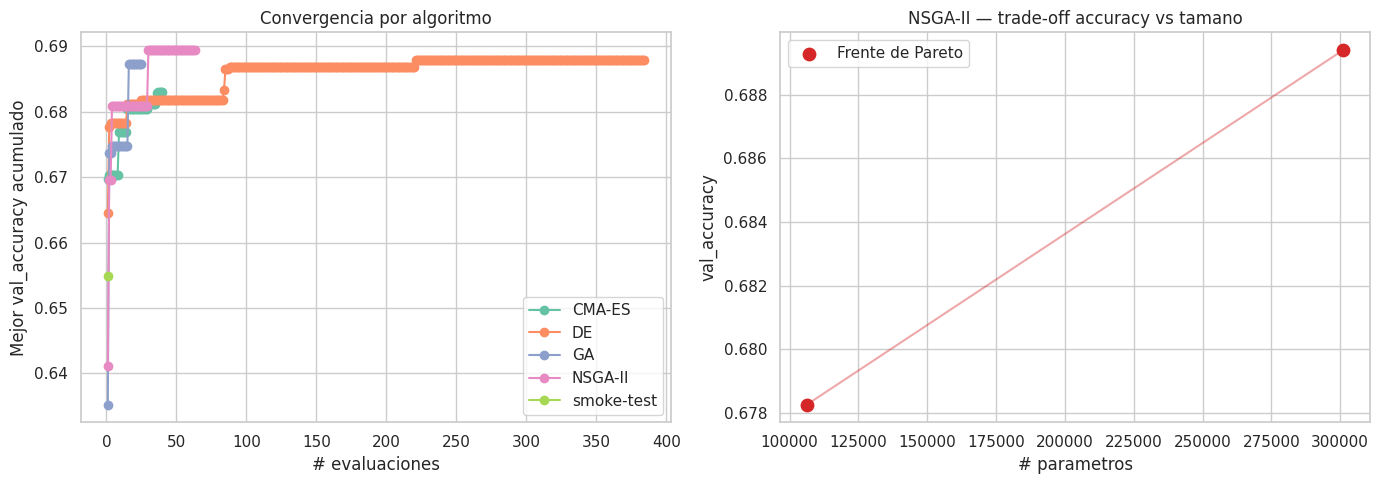

In [17]:
# Evolucion del mejor val_acc a lo largo de las evaluaciones
eval_df = pd.DataFrame(EVAL_LOG)
eval_df["cummax"] = eval_df.groupby("algo")["val_acc"].cummax()
eval_df["eval_idx"] = eval_df.groupby("algo").cumcount() + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for algo, sub in eval_df.groupby("algo"):
    axes[0].plot(sub["eval_idx"], sub["cummax"], marker="o", label=algo)
axes[0].set_xlabel("# evaluaciones")
axes[0].set_ylabel("Mejor val_accuracy acumulado")
axes[0].set_title("Convergencia por algoritmo")
axes[0].legend()

# Frente de Pareto NSGA-II
front_df = pd.DataFrame([
    {"val_acc": ind.fitness.values[0], "n_params": ind.fitness.values[1]}
    for ind in front_nsga
]).sort_values("n_params")
axes[1].scatter(front_df["n_params"], front_df["val_acc"], s=80, color="tab:red",
                label="Frente de Pareto")
axes[1].plot(front_df["n_params"], front_df["val_acc"], color="tab:red", alpha=0.4)
axes[1].set_xlabel("# parametros")
axes[1].set_ylabel("val_accuracy")
axes[1].set_title("NSGA-II — trade-off accuracy vs tamano")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Test final del mejor modelo encontrado

Se toma el **mejor individuo global** (cualquier algoritmo), se reentrena con mas epocas y se evalua en **test**.

In [ ]:
overall_best_row = summary.iloc[0]
overall_params = {k: overall_best_row[k] for k in PARAM_NAMES}
# Restaurar tipos
overall_params["n_hidden1"] = int(overall_params["n_hidden1"])
overall_params["n_hidden2"] = int(overall_params["n_hidden2"])
overall_params["batch_size"] = int(overall_params["batch_size"])

print(f"Mejor overall: {overall_best_row['algoritmo']}")
print(f"  val_acc (busqueda)   = {overall_best_row['best_val_acc']:.4f}")
print(f"  params: {describe(overall_params)}\n")

model_best = build_model(overall_params)
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=7,
                                  restore_best_weights=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                      patience=3, min_lr=1e-6, verbose=0),
]
history = model_best.fit(
    X_train_dense, y_train_oh,
    validation_data=(X_val_dense, y_val_oh),
    epochs=60,
    batch_size=overall_params["batch_size"],
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=0,
)
epochs_trained = len(history.history["loss"])
test_loss, test_acc = model_best.evaluate(X_test_dense, y_test_oh, verbose=0)
print(f"Entrenamiento detenido en epoca {epochs_trained}")
print(f"TEST accuracy = {test_acc:.4f}  (loss = {test_loss:.4f})")

Mejor overall: NSGA-II (best acc)
  val_acc (busqueda)   = 0.6894
  params: h1= 214  h2= 159  do1=0.49  do2=0.38  lr=5.3e-04  bs=128  leaky=0.087

Entrenamiento detenido en epoca 13
TEST accuracy = 0.6547  (loss = 0.7696)


: 

## 10. Conclusiones

### Que hace cada algoritmo

- **GA canonico (DEAP):** balance estandar explorar/explotar. Bueno como referencia didactica, pero no adapta la distribucion de busqueda.
- **CMA-ES:** adapta la matriz de covarianza en cada generacion — converge mas rapido en espacios continuos correlacionados. Suele ser el mas fuerte con presupuestos bajos.
- **Differential Evolution:** simple de implementar, compite con CMA-ES en varios problemas. Sensible a los parametros `mutation` y `recombination`.
- **NSGA-II:** no devuelve un punto unico sino un **frente de Pareto** accuracy vs tamano. Util cuando existen restricciones de deployment (latencia, memoria).

### Presupuesto computacional

Los presupuestos definidos (8-12 individuos, 5 generaciones, 10 epocas por evaluacion) estan ajustados para correr el notebook en pocos minutos. Para obtener resultados mas finos aumentar `pop_size`, `n_gen` y `EVAL_EPOCHS`.

### Cache de evaluaciones

Todos los algoritmos comparten `_EVAL_CACHE`. Cuando uno explora un genoma ya visto por otro, reutiliza el resultado. Esto abarata las corridas sucesivas.

### Como seguir

1. Aumentar presupuesto (pop, gen, epocas) y re-correr para resultados mas robustos.
2. Probar **BOHB** / **Hyperband** como baseline competitivo no-evolutivo.
3. Usar NSGA-II con objetivos reales de negocio (p.ej. latencia de inferencia medida directamente).